In [3]:
import strawberryfields as sf
from strawberryfields.ops import *

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Fock States


In [38]:
#Initialize the engine and program with one quantum mode/system
prog_fock = sf.Program(1)

In [39]:
with prog_fock.context as q:
    Fock(8) | q[0]

In [40]:
#run the engine and get the state
eng_fock = sf.Engine("fock", backend_options={"cutoff_dim": 10})
state_fock = eng_fock.run(prog_fock).state

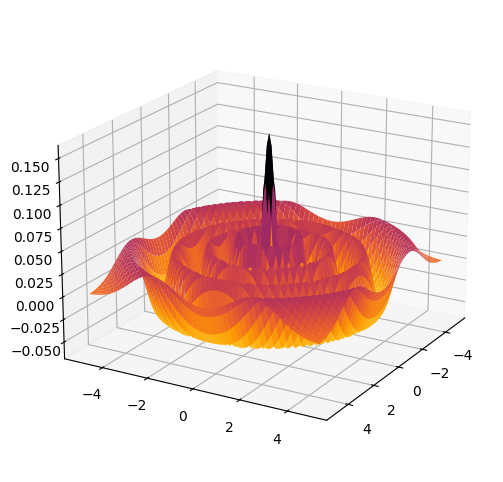

In [41]:
X = np.arange(-5, 5, 0.1)
P = np.arange(-5, 5, 0.1)
Z = state_fock.wigner(0, X, P)
X, P = np.meshgrid(X, P)
ax = plt.figure(figsize=(8, 6)).add_subplot(projection='3d')
ax.plot_surface(X, P, Z, cmap='inferno_r')
ax.view_init(elev=20, azim=30)

plt.show()

# Coherent States

The convention of the quadratures is

$$ \hat{x} = \hat{\alpha} + \hat{\alpha}^{\dagger} $$
$$ \hat{p} = (\hat{\alpha} - \hat{\alpha}^{\dagger})/i $$

Resulting in the coherent state being centered at 

$$ (2\text{Re}(\alpha), 2\text{Im}(\alpha)) $$

in the phase space, where $\alpha$ is the complex amplitude of the coherent state $\ket{a} = \hat{D}(a)\ket{0}$

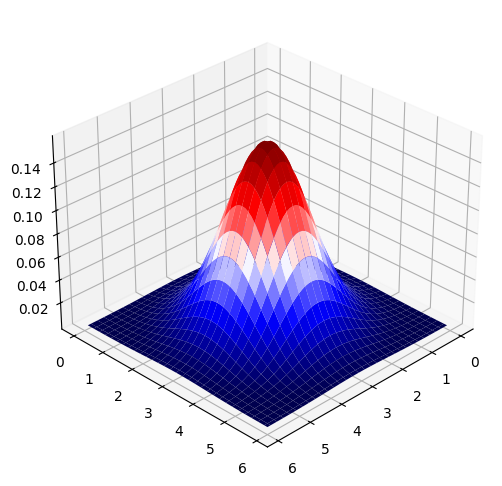

In [4]:
prog_coherent = sf.Program(1)

with prog_coherent.context as q:
    alpha = 1.5 + 1.5j
    r = np.abs(alpha)
    phi = np.angle(alpha)
    Coherent(r, phi) | q[0]

#run the engine and get the state
eng_coherent = sf.Engine("gaussian")
state_coherent = eng_coherent.run(prog_coherent).state

X = np.arange(0, 6, 0.1)
P = np.arange(0, 6, 0.1)
Z = state_coherent.wigner(0, X, P)
X, P = np.meshgrid(X, P)
ax = plt.figure(figsize=(8, 6)).add_subplot(projection='3d')
ax.plot_surface(X, P, Z, cmap='seismic')
ax.view_init(elev=30, azim=45)

plt.show()

In [5]:
type(alpha)

complex

# Squeezed States

# Displaced Squeezed States